<a href="https://colab.research.google.com/github/Lathika-M732/24ADI006-DEEP-LEARNING/blob/main/EX_3_DL_LAB_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# IMPLEMENTATION OF CONVOLUTIONAL NEURAL NETWORKS (CNNs) FOR IMAGE CLASSIFICATION

## Name     :  Lathika M
## Roll No  :  24BAD062

# TASK A — Load Dataset and Preprocess the Data

In [4]:
# TASK A
# CNN FOR ANEMIA CLASSIFICATION
# DATASET LOADING AND PREPROCESSING

# 1. Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix

# 2. Student Details

STUDENT_NAME = "Lathika M"
ROLL_NO = "24BAD062"
print("=" * 60)
print("        CNN - ANEMIA CLASSIFICATION")
print("=" * 60)
print("Name     :", STUDENT_NAME)
print("Roll No  :", ROLL_NO)
print("=" * 60)

# 3. Upload Dataset

from google.colab import files

uploaded = files.upload()

file_name = list(uploaded.keys())[0]
df = pd.read_csv(file_name)

# 4. Display Dataset

print("\nDataset Shape:", df.shape)

print("\nFirst 5 Rows:")
display(df.head())

print("\nColumn Names:")
print(df.columns.tolist())

# 5. Clean Column Names

df.columns = df.columns.str.strip()

print("\nCleaned Column Names:")
print(df.columns.tolist())

# 6. Check Missing Values

print("\nMissing Values:")
print(df.isnull().sum())

# 7. Remove Unnecessary Column

if 'Name' in df.columns:
    df = df.drop('Name', axis=1)

# 8. Convert Target Variable

df['Anaemic'] = df['Anaemic'].map({
    'Yes': 1,
    'No': 0
})

# 9. Convert Sex

df['Sex'] = df['Sex'].map({
    'M': 0,
    'F': 1
})

# 10. Separate Features and Target

X = df.drop('Anaemic', axis=1)
y = df['Anaemic']

print("\nFeatures:")
print(X.columns.tolist())

print("\nTarget:")
print("Anaemic")

# 11. Train-Test Split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

# 12. Feature Scaling

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# 13. Reshape for 1D CNN

X_train = X_train.reshape(
    X_train.shape[0],
    X_train.shape[1],
    1
)

X_test = X_test.reshape(
    X_test.shape[0],
    X_test.shape[1],
    1
)

# 14. Final Output

print("\n" + "=" * 60)
print("PREPROCESSING COMPLETED")
print("=" * 60)
print("Name              :", STUDENT_NAME)
print("Roll No           :", ROLL_NO)
print("Training Samples  :", X_train.shape[0])
print("Testing Samples   :", X_test.shape[0])
print("Number of Features:", X_train.shape[1])
print("CNN Input Shape   :", X_train.shape[1:])
print("=" * 60)

        CNN - ANEMIA CLASSIFICATION
Name     : Lathika M.
Roll No  : 24BAD062


Saving Anemia_Dataset,csv.csv to Anemia_Dataset,csv (1).csv

Dataset Shape: (104, 7)

First 5 Rows:


,Name,Sex,%Red Pixel,%Green pixel,%Blue pixel,Hb,Anaemic
0,Shahalam,M,47.6372,26.7953,25.5675,15.1,No
1,Md.Ismail,M,45.6906,30.0735,24.2359,9.1,Yes
2,Saiful,M,43.4098,31.2315,25.3586,12.9,No
3,Yamin,M,44.4252,28.7436,26.8312,14.7,No
4,Tarek,M,44.3297,28.7617,26.9086,14.1,No



Column Names:
['Name', 'Sex', '   %Red Pixel', '%Green pixel', '%Blue pixel', 'Hb', 'Anaemic']

Cleaned Column Names:
['Name', 'Sex', '%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb', 'Anaemic']

Missing Values:
Name            0
Sex             0
%Red Pixel      0
%Green pixel    0
%Blue pixel     0
Hb              0
Anaemic         0
dtype: int64

Features:
['Sex', '%Red Pixel', '%Green pixel', '%Blue pixel', 'Hb']

Target:
Anaemic

PREPROCESSING COMPLETED
Name              : Lathika M.
Roll No           : 24BAD062
Training Samples  : 83
Testing Samples   : 21
Number of Features: 5
CNN Input Shape   : (5, 1)


# TASK B — Build and Train CNN Model

In [5]:
# TASK B
# BUILDING AND TRAINING A 1D CNN MODEL

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D, MaxPooling1D
from tensorflow.keras.layers import Flatten, Dense, Dropout
from tensorflow.keras.optimizers import Adam

# Student Details

STUDENT_NAME = "Lathika M."
ROLL_NO = "24BAD062"

print("=" * 60)
print("        CNN MODEL TRAINING")
print("=" * 60)
print("Name    :", STUDENT_NAME)
print("Roll No :", ROLL_NO)
print("=" * 60)

# 1. Build CNN Model

model = Sequential([

    # First Convolution Layer
    Conv1D(
        filters=32,
        kernel_size=2,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    ),

    # Pooling Layer
    MaxPooling1D(pool_size=2),

    # Second Convolution Layer
    Conv1D(
        filters=64,
        kernel_size=2,
        activation='relu'
    ),

    # Flatten
    Flatten(),

    # Fully Connected Layer
    Dense(64, activation='relu'),

    # Dropout
    Dropout(0.3),

    # Output Layer
    Dense(1, activation='sigmoid')
])

# 2. Display Model

print("\nCNN MODEL SUMMARY:\n")

model.summary()

# 3. Compile Model

model.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Train Model

history = model.fit(
    X_train,
    y_train,
    epochs=30,
    batch_size=8,
    validation_split=0.2,
    verbose=1
)

# 5. Evaluate Model

test_loss, test_accuracy = model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# 6. Display Result

print("\n" + "=" * 60)
print("CNN TRAINING COMPLETED")
print("=" * 60)

print("Name           :", STUDENT_NAME)
print("Roll No        :", ROLL_NO)
print("Test Loss      :", round(test_loss, 4))
print("Test Accuracy  :", round(test_accuracy * 100, 2), "%")

print("=" * 60)

        CNN MODEL TRAINING
Name    : Lathika M.
Roll No : 24BAD062

CNN MODEL SUMMARY:



/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)               │ (None, 4, 32)          │            96 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 2, 32)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_3 (Conv1D)               │ (None, 1, 64)          │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,481 (33.13 KB)

 Trainable params: 8,481 (33.13 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 2s 53ms/step - accuracy: 0.6667 - loss: 0.6783 - val_accuracy: 0.8235 - val_loss: 0.6397
Epoch 2/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8182 - loss: 0.6322 - val_accuracy: 0.9412 - val_loss: 0.5882
Epoch 3/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8485 - loss: 0.5923 - val_accuracy: 0.8824 - val_loss: 0.5284
Epoch 4/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8182 - loss: 0.5342 - val_accuracy: 0.9412 - val_loss: 0.4698
Epoch 5/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8636 - loss: 0.4811 - val_accuracy: 0.9412 - val_loss: 0.4192
Epoch 6/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8939 - loss: 0.4198 - val_accuracy: 1.0000 - val_loss: 0.3421
Epoch 7/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8333 - loss: 0.3965 - val_accuracy: 0.8824 - val_loss: 0.3062
Epoch 8/30
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.9242 - loss: 0.3205 - val_accuracy: 0.8824 - val_loss: 0.2692


# TASK C — Accuracy, Loss Graph and Confusion Matrix

        CNN MODEL EVALUATION
Name    : Lathika M.
Roll No : 24BAD062
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step

CONFUSION MATRIX:
[[12  4]
 [ 0  5]]

CLASSIFICATION REPORT:
              precision    recall  f1-score   support

 Non-Anaemic       1.00      0.75      0.86        16
     Anaemic       0.56      1.00      0.71         5

    accuracy                           0.81        21
   macro avg       0.78      0.88      0.79        21
weighted avg       0.89      0.81      0.82        21



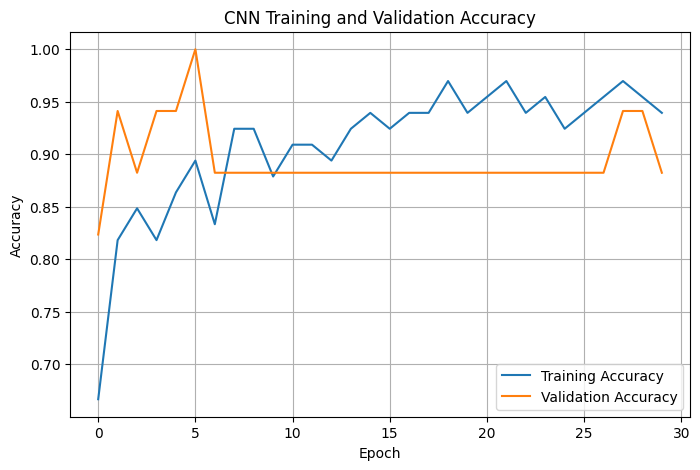

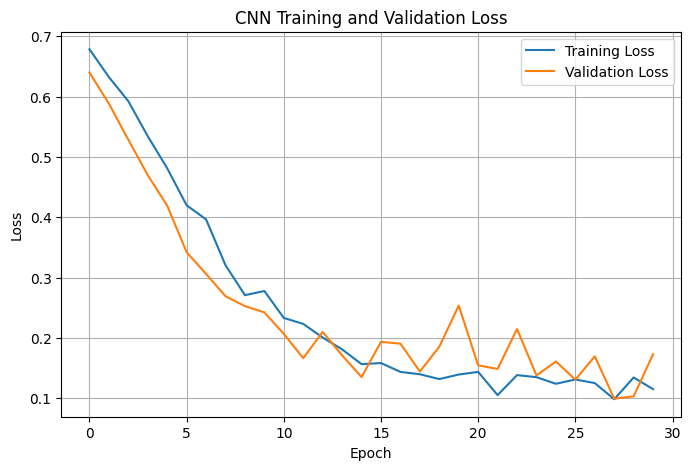

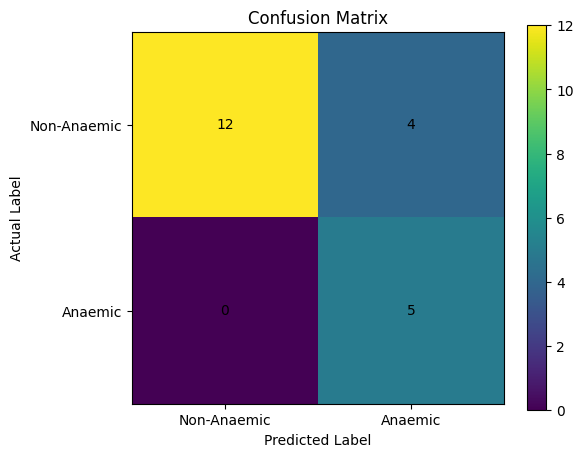

EVALUATION COMPLETED
Name    : Lathika M.
Roll No : 24BAD062


In [6]:
# TASK C
# MODEL EVALUATION AND VISUALIZATION

import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Student Details

STUDENT_NAME = "Lathika M."
ROLL_NO = "24BAD062"

print("=" * 60)
print("        CNN MODEL EVALUATION")
print("=" * 60)
print("Name    :", STUDENT_NAME)
print("Roll No :", ROLL_NO)
print("=" * 60)

# 1. Predict Test Data

y_probability = model.predict(X_test)

y_pred = (y_probability >= 0.5).astype(int).flatten()

# 2. Confusion Matrix

cm = confusion_matrix(y_test, y_pred)

print("\nCONFUSION MATRIX:")
print(cm)

# 3. Classification Report

print("\nCLASSIFICATION REPORT:")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=['Non-Anaemic', 'Anaemic']
    )
)

# 4. Plot Training Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title('CNN Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)

plt.show()

# 5. Plot Training Loss

plt.figure(figsize=(8, 5))

plt.plot(
    history.history['loss'],
    label='Training Loss'
)

plt.plot(
    history.history['val_loss'],
    label='Validation Loss'
)

plt.title('CNN Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)

plt.show()

# 6. Confusion Matrix Plot

plt.figure(figsize=(6, 5))

plt.imshow(cm)

plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('Actual Label')

plt.xticks(
    [0, 1],
    ['Non-Anaemic', 'Anaemic']
)

plt.yticks(
    [0, 1],
    ['Non-Anaemic', 'Anaemic']
)

# Add values inside matrix

for i in range(2):
    for j in range(2):
        plt.text(
            j,
            i,
            cm[i, j],
            ha='center',
            va='center'
        )

plt.colorbar()
plt.show()

# 7. Final Output

print("=" * 60)
print("EVALUATION COMPLETED")
print("=" * 60)
print("Name    :", STUDENT_NAME)
print("Roll No :", ROLL_NO)
print("=" * 60)

# TASK D — Improve CNN Using Data Augmentation / Hyperparameter Tuning

        IMPROVED CNN MODEL
Name    : Lathika M.
Roll No : YOUR ROLL NO

IMPROVED CNN MODEL:



/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d_4 (Conv1D)               │ (None, 4, 64)          │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_2 (MaxPooling1D)  │ (None, 2, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_5 (Conv1D)               │ (None, 1, 128)         │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_2 (Flatten)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        16,512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,345 (130.25 KB)

 Trainable params: 33,345 (130.25 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 5s 104ms/step - accuracy: 0.7576 - loss: 0.6525 - val_accuracy: 0.8235 - val_loss: 0.5923
Epoch 2/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8030 - loss: 0.5900 - val_accuracy: 0.8235 - val_loss: 0.5370
Epoch 3/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 0.7576 - loss: 0.5582 - val_accuracy: 0.8235 - val_loss: 0.4811
Epoch 4/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8030 - loss: 0.5113 - val_accuracy: 0.8824 - val_loss: 0.4343
Epoch 5/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8182 - loss: 0.4764 - val_accuracy: 0.9412 - val_loss: 0.3893
Epoch 6/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.8939 - loss: 0.4166 - val_accuracy: 0.9412 - val_loss: 0.3587
Epoch 7/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9091 - loss: 0.3750 - val_accuracy: 0.8824 - val_loss: 0.3345
Epoch 8/50
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.9545 - loss: 0.3405 - val_accuracy: 0.8824 - val_loss: 0.3051

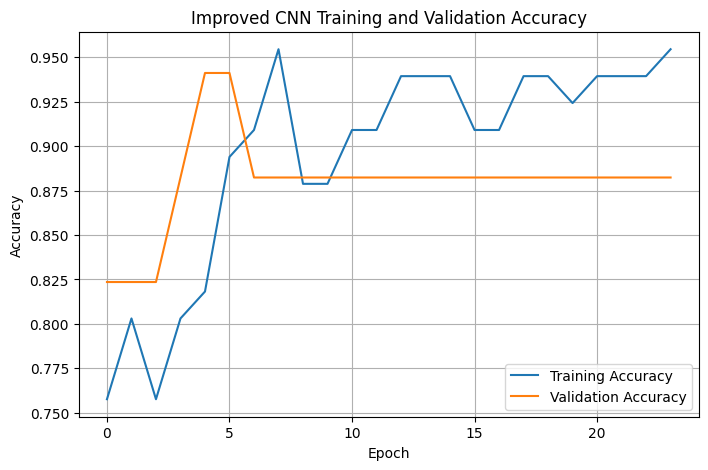

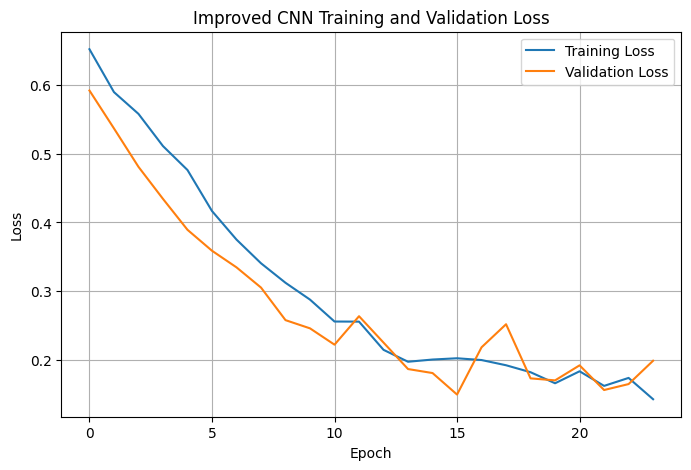

In [7]:
# TASK D
# IMPROVED CNN MODEL
# HYPERPARAMETER TUNING + DROPOUT + EARLY STOPPING

import tensorflow as tf

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv1D
from tensorflow.keras.layers import MaxPooling1D
from tensorflow.keras.layers import Flatten
from tensorflow.keras.layers import Dense
from tensorflow.keras.layers import Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

# Student Details

STUDENT_NAME = "Lathika M."
ROLL_NO = "YOUR ROLL NO"

print("=" * 60)
print("        IMPROVED CNN MODEL")
print("=" * 60)
print("Name    :", STUDENT_NAME)
print("Roll No :", ROLL_NO)
print("=" * 60)

# 1. Create Improved CNN

improved_model = Sequential([

    # First CNN layer
    Conv1D(
        filters=64,
        kernel_size=2,
        activation='relu',
        input_shape=(X_train.shape[1], 1)
    ),

    MaxPooling1D(pool_size=2),

    # Second CNN layer
    Conv1D(
        filters=128,
        kernel_size=2,
        activation='relu'
    ),

    Flatten(),

    # Dense layer
    Dense(
        128,
        activation='relu'
    ),

    # Dropout
    Dropout(0.5),

    # Output layer
    Dense(
        1,
        activation='sigmoid'
    )
])

# 2. Display Model

print("\nIMPROVED CNN MODEL:\n")

improved_model.summary()

# 3. Compile Model

improved_model.compile(
    optimizer=Adam(
        learning_rate=0.0005
    ),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

# 4. Early Stopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=8,
    restore_best_weights=True
)

# 5. Train Improved Model

improved_history = improved_model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=8,
    validation_split=0.2,
    callbacks=[early_stop],
    verbose=1
)

# 6. Evaluate Model

improved_loss, improved_accuracy = improved_model.evaluate(
    X_test,
    y_test,
    verbose=0
)

# 7. Predictions

improved_probability = improved_model.predict(X_test)

improved_pred = (
    improved_probability >= 0.5
).astype(int).flatten()

# 8. Confusion Matrix

improved_cm = confusion_matrix(
    y_test,
    improved_pred
)

# 9. Final Result

print("\n" + "=" * 60)
print("IMPROVED CNN RESULTS")
print("=" * 60)

print("Name                :", STUDENT_NAME)
print("Roll No             :", ROLL_NO)
print("Improved Test Loss  :", round(improved_loss, 4))

print(
    "Improved Accuracy   :",
    round(improved_accuracy * 100, 2),
    "%"
)

print("\nConfusion Matrix:")
print(improved_cm)

print("\nClassification Report:")

print(
    classification_report(
        y_test,
        improved_pred,
        target_names=[
            'Non-Anaemic',
            'Anaemic'
        ]
    )
)

print("=" * 60)

# 10. Plot Improved Accuracy

plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history['accuracy'],
    label='Training Accuracy'
)

plt.plot(
    improved_history.history['val_accuracy'],
    label='Validation Accuracy'
)

plt.title(
    'Improved CNN Training and Validation Accuracy'
)

plt.xlabel('Epoch')
plt.ylabel('Accuracy')

plt.legend()
plt.grid(True)

plt.show()

# 11. Plot Improved Loss

plt.figure(figsize=(8, 5))

plt.plot(
    improved_history.history['loss'],
    label='Training Loss'
)

plt.plot(
    improved_history.history['val_loss'],
    label='Validation Loss'
)

plt.title(
    'Improved CNN Training and Validation Loss'
)

plt.xlabel('Epoch')
plt.ylabel('Loss')

plt.legend()
plt.grid(True)

plt.show()